
Reading folder: 20260810_DGUdial_P2_F005_F006_F007
Could not load README.txt: Error tokenizing data. C error: Expected 1 fields in line 8, saw 2


Reading folder: 20260817_DGUdial_P2_F005_F006_F007_ProperResolution
Could not load README.txt: Error tokenizing data. C error: Expected 1 fields in line 8, saw 2


Available spectra:
"20260810_Baseline_DOCD2O1pc.txt",
"20260810_F005LP_6FBz@P2_DGUdial.txt",
"20260810_F006WA_phDADQ@P2_DGUdial.txt",
"20260810_F007WA_1BrC18@P2_DGUdial.txt",
"20260810_P2_DGUdial.txt",
"20260817_Baseline_DOCD2O1pc.txt",
"20260817_F005LP_6FBz@P2_DGUdial.txt",
"20260817_F006WA_phDADQ@P2_DGUdial.txt",
"20260817_F007WA_1BrC18@P2_DGUdial.txt",
"20260817_P2_DGUdial.txt",


C:\Users\cborja\AppData\Local\Temp\ipykernel_25700\1966296283.py:137: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(style.get("grid", False), alpha=0.3)



Figure saved successfully to:
H:\FUBerlin\DataAnalysis\UVvisNIR\NT26_PosterFigures_DGUdialSamples\UVvisNIR_DGUdial.svg


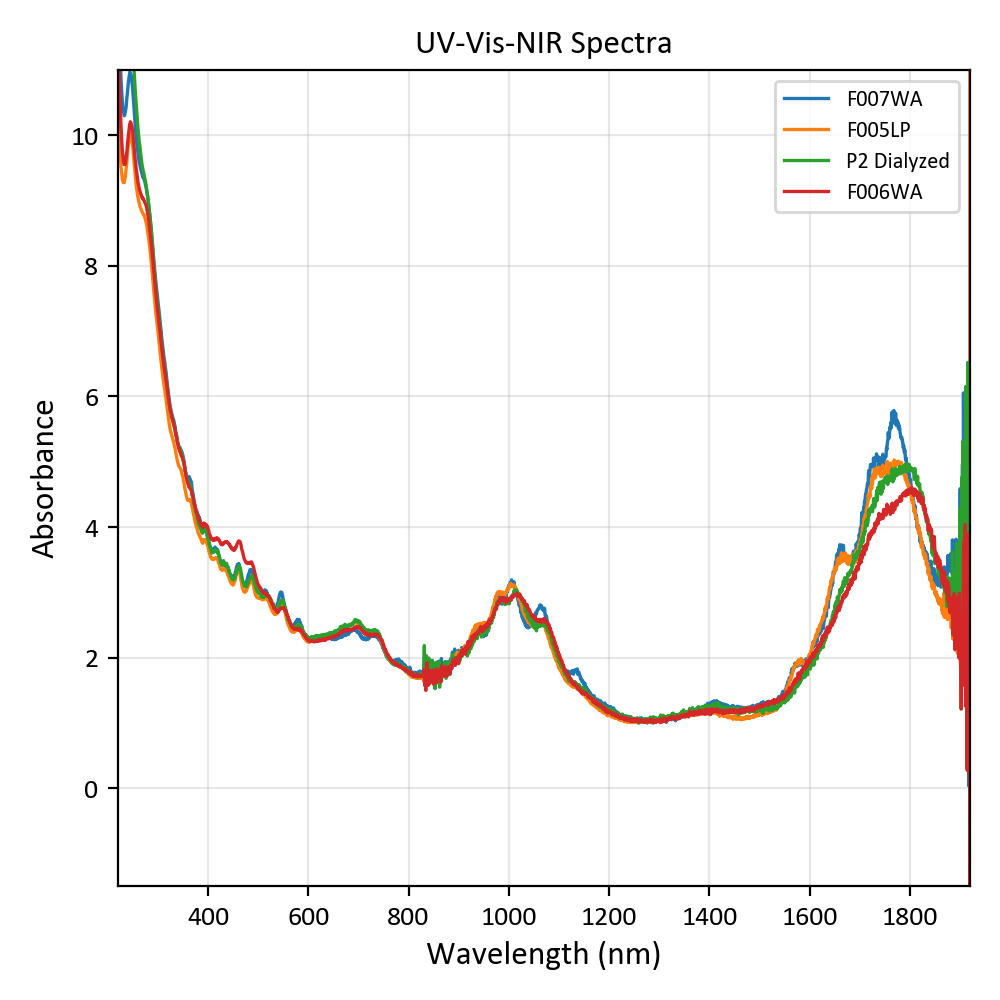

In [5]:
%matplotlib widget
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib


# ============================================================
# 1. STYLE CONFIGURATION (Imported from Raman Script)
# ============================================================

poster_style = {
    "figsize": (5,5),          # Adjust to fit your poster columns
    "dpi": 200,                 # High resolution for export
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,              # Easily toggle grid True/False
    "colors": None              # e.g., ["#1f77b4", "#ff7f0e", "#2ca02c"]
}


# ============================================================
# 2. LOAD UV-VIS-NIR TXT SPECTRA
# ============================================================

txt_folders = [
    r"H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260810_DGUdial_P2_F005_F006_F007",
    r"H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260817_DGUdial_P2_F005_F006_F007_ProperResolution",
]

txt_spectra = {}

for txt_folder in txt_folders:
    print(f"\nReading folder: {os.path.basename(txt_folder)}")
    
    for file in os.listdir(txt_folder):
        if not file.lower().endswith(".txt"):
            continue

        path = os.path.join(txt_folder, file)

        try:
            df = pd.read_csv(
                path,
                sep="\t",
                skiprows=1,
                dtype=str
            )
            df.columns = ["Wavelength", "Abs"]

            # Clean decimal separators
            df["Wavelength"] = df["Wavelength"].str.strip().str.replace(",", ".", regex=False)
            df["Abs"] = df["Abs"].str.strip().str.replace(",", ".", regex=False)

            # Convert to numbers
            df["Wavelength"] = pd.to_numeric(df["Wavelength"], errors="coerce")
            df["Abs"] = pd.to_numeric(df["Abs"], errors="coerce")

            # Remove invalid rows & sort
            df = df.dropna().sort_values("Wavelength").reset_index(drop=True)
            txt_spectra[file] = df

        except Exception as e:
            print(f"Could not load {file}: {e}")

print("\nAvailable spectra:")
for name in txt_spectra:
    print(f'"{name}",')


# ============================================================
# 3. SELECT YOUR EXPERIMENTAL SPECTRA
# ============================================================

spectra_to_plot = [
    "20260817_F007WA_1BrC18@P2_DGUdial.txt",
    "20260817_F005LP_6FBz@P2_DGUdial.txt",
    "20260817_P2_DGUdial.txt",
    "20260817_F006WA_phDADQ@P2_DGUdial.txt",
]

selected_spectra = {name: txt_spectra[name] for name in spectra_to_plot if name in txt_spectra}


# ============================================================
# 4. PLOT FUNCTION (Upgraded with Raman Style Logic)
# ============================================================

def PlotSpectra(
        spectra_dict,
        spectra_names,
        style=poster_style,
        offset_step=0.0,
        xmin=None, xmax=None,
        ymin=None, ymax=None,
        ylabel="Absorbance",
        custom_labels=None,
        save_path=None
):
    plt.figure(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({
        "font.size": style["font_size"],
        "font.family": style["font_family"]
    })
    
    colors = style.get("colors")
    
    for i, name in enumerate(spectra_names):
        if name not in spectra_dict:
            print(f"WARNING: {name} not found")
            continue

        df = spectra_dict[name]
        X = df["Wavelength"].values
        Y = df["Abs"].values + (i * offset_step)
        
        # Determine label and color
        label = custom_labels[i] if custom_labels and i < len(custom_labels) else name
        c = colors[i % len(colors)] if colors else None

        plt.plot(X, Y, label=label, linewidth=style["line_width"], color=c)

    plt.xlabel("Wavelength (nm)", fontsize=style["label_size"])
    plt.ylabel(ylabel, fontsize=style["label_size"])
    plt.title("UV-Vis-NIR Spectra", fontsize=style["title_size"])

    if xmin is not None or xmax is not None:
        plt.xlim(xmin, xmax)
    if ymin is not None or ymax is not None:
        plt.ylim(ymin, ymax)
        
    plt.grid(style.get("grid", False), alpha=0.3)
    plt.legend(fontsize=style["legend_size"])
    plt.tight_layout()
    
    # Save before showing! (Fixes the blank output bug)
    if save_path:
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=style["dpi"], bbox_inches="tight")
        print(f"\nFigure saved successfully to:\n{save_path}")
        
    plt.show()


# ============================================================
# 5. BASELINE SUBTRACTION
# ============================================================

baseline_name = "20260817_Baseline_DOCD2O1pc.txt"
baseline = txt_spectra[baseline_name]

def SubtractBaseline(spectra_input, baseline_df):
    corrected_spectra = {}
    baseline_x = baseline_df["Wavelength"].values
    baseline_y = baseline_df["Abs"].values
    
    for name, df in spectra_input.items():
        measured_x = df["Wavelength"].values
        measured_y = df["Abs"].values
        
        baseline_interpolated = np.interp(measured_x, baseline_x, baseline_y)
        corrected = df.copy()
        corrected["Abs"] = measured_y - baseline_interpolated
        corrected_spectra[name] = corrected
        
    return corrected_spectra

baseline_corrected_spectra = SubtractBaseline(selected_spectra, baseline)


# ============================================================
# 6. LOAD WATER CALIBRATION FILE
# ============================================================

References = r"H:\FUBerlin\Measurements\UVvisNIR\References.csv"

calibration_df = pd.read_csv(
    References, sep=",", skiprows=2, header=None,
    names=[
        "Water_Wavelength", "WaterInD2O",
        "Nicodenz_Wavelength", "Nicodenz",
        "Empty_Wavelength", "Empty_P2",
        "WaterFilled_Wavelength", "WaterFilled"
    ]
)

calibration_spectra = {}
for i in range(0, len(calibration_df.columns), 2):
    wavelength_col = calibration_df.columns[i]
    absorbance_col = calibration_df.columns[i + 1]
    
    spectrum = pd.DataFrame({
        "Wavelength": pd.to_numeric(calibration_df[wavelength_col], errors="coerce"),
        "Abs": pd.to_numeric(calibration_df[absorbance_col], errors="coerce")
    }).dropna().sort_values("Wavelength").reset_index(drop=True)
    
    calibration_spectra[absorbance_col] = spectrum

water_calibration = calibration_spectra["WaterInD2O"]


# ============================================================
# 7. WATER CALIBRATION SUBTRACTION
# ============================================================

def ApplyCalibrationCorrection(spectra_input, calibration_spectrum, cal_factors):
    corrected_spectra = {}
    calibration_x = calibration_spectrum["Wavelength"].values
    calibration_y = calibration_spectrum["Abs"].values
    
    for name, df in spectra_input.items():
        if name not in cal_factors:
            continue
            
        factor = cal_factors[name]
        measured_x = df["Wavelength"].values
        measured_y = df["Abs"].values
        
        calibration_interpolated = np.interp(measured_x, calibration_x, calibration_y)
        corrected = df.copy()
        corrected["Abs"] = measured_y - (factor * calibration_interpolated)
        corrected_spectra[name] = corrected
        
    return corrected_spectra


calibration_factors = {
    "20260817_F007WA_1BrC18@P2_DGUdial.txt": 0.2,
    "20260817_F005LP_6FBz@P2_DGUdial.txt": 1.5,
    "20260817_P2_DGUdial.txt": 0,
    "20260817_F006WA_phDADQ@P2_DGUdial.txt": 0.3,
}

water_corrected_spectra = ApplyCalibrationCorrection(
    baseline_corrected_spectra, 
    water_calibration, 
    calibration_factors
)


# ============================================================
# 8. NORMALIZATION
# ============================================================

def NormalizeSpectra(spectra_input, xmin, xmax, mode="M"):
    normalized = {}
    for name, df in spectra_input.items():
        df_norm = df.copy()
        X = df_norm["Wavelength"].values
        Y = df_norm["Abs"].values
        
        mask = (X >= xmin) & (X <= xmax)
        X_window = X[mask]
        Y_window = Y[mask]
        
        if len(X_window) == 0:
            print(f"No normalization range for {name}")
            continue
            
        if mode.upper() == "M": factor = np.max(Y_window)
        elif mode.upper() == "I": factor = np.trapezoid(Y_window, X_window)
        elif mode.upper() == "V": factor = np.min(Y_window)
        else: raise ValueError("Mode must be 'M', 'I', or 'V'")
            
        if factor == 0: continue
            
        df_norm["Abs"] = Y / factor
        normalized[name] = df_norm
    return normalized

normalized_spectra = NormalizeSpectra(
    water_corrected_spectra,
    xmin=1200,
    xmax=1350,
    mode="V"
)


# ============================================================
# 9. FINAL PLOT
# ============================================================

# Use this to map clean names to your legend instead of full filenames!
clean_labels = [
    "F007WA",
    "F005LP",
    "P2 Dialyzed",
    "F006WA"
]

pathFigures = r"H:\FUBerlin\DataAnalysis\UVvisNIR\NT26_PosterFigures_DGUdialSamples"
output_file = os.path.join(pathFigures, "UVvisNIR_DGUdial.svg")

PlotSpectra(
    spectra_dict=normalized_spectra,
    spectra_names=spectra_to_plot,
    style=poster_style,               # <--- Using the Raman style dictionary here!
    custom_labels=clean_labels,       # <--- Using clean labels here!
    offset_step=-0.0,
    xmin=220, xmax=1920,
    ymin=-1.5, ymax=11,
    ylabel="Absorbance",
    save_path=output_file             # <--- Saves the figure via the updated function
)
plt.gca().set_yticklabels([])
plt.grid(True)

C:\Users\cborja\AppData\Local\Temp\ipykernel_25700\1427650161.py:137: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(style.get("grid", False), alpha=0.3)


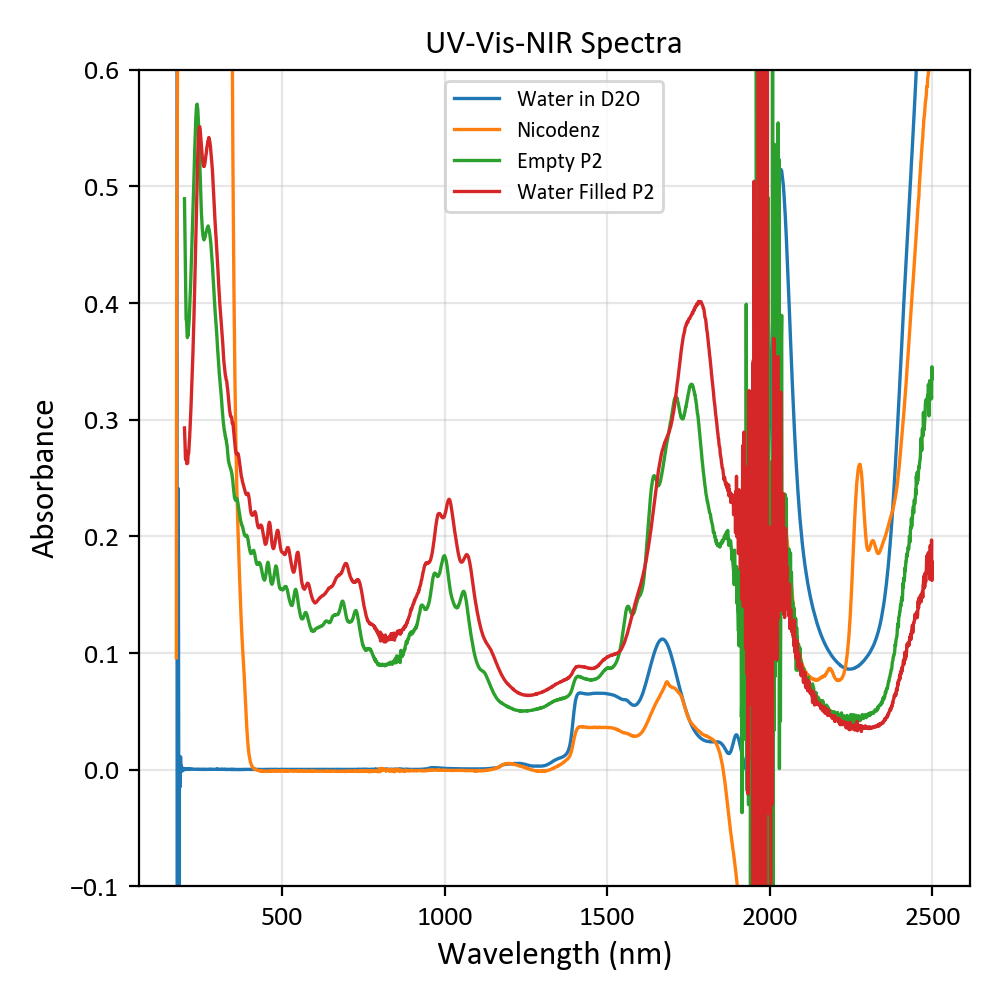

In [2]:
# ==========================
# PLOT CALIBRATION SPECTRA
# ==========================

calibration_to_plot = [
    "WaterInD2O",
    "Nicodenz",
    "Empty_P2",
    "WaterFilled",
]

# 2. Plot using the upgraded function
PlotSpectra(
    spectra_dict=calibration_spectra,
    spectra_names=calibration_to_plot,
    style=poster_style,         # <--- Pass the custom style here!
    offset_step=0.0,
    # xmin=200,
    # xmax=2400,
    ymin=-0.1,
    ymax=0.6,
    ylabel="Absorbance",
    custom_labels=["Water in D2O", "Nicodenz", "Empty P2", "Water Filled P2"], # Optional: make legend pretty
    # save_path=r"C:\Your\Path\Calibration.svg"  # Optional: uncomment to save
)